In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from stockFunctions import rmse_mape

warnings.filterwarnings("ignore")


In [16]:
df = pd.read_csv(r'D:\HopeAI\Assignments\12. Time_Series\3.TS-Models\Tatacoffee13_21.csv',
                  parse_dates=True, index_col="Date")
close = df["Close"].to_frame()

train_size = round(len(close) * 0.80)
train_data, test_data = close.iloc[:train_size], close.iloc[train_size:]

scaler = MinMaxScaler()
train = scaler.fit_transform(train_data)
test = scaler.transform(test_data)

df


,Open,High,Low,Close
Date,,,,
2013-01-01,1410.60,1427.90,1408.30,1415.10
2013-01-02,1421.00,1626.60,1416.15,1607.40
2013-01-03,1632.55,1673.90,1613.05,1626.20
2013-01-04,1627.75,1627.75,1574.60,1579.05
2013-01-07,1580.00,1639.50,1565.50,1595.65
...,...,...,...,...
2021-12-22,202.90,207.80,201.35,205.00
2021-12-23,206.00,206.85,202.05,202.95
2021-12-24,203.90,203.90,199.35,201.00


In [17]:
def finalize_and_plot(best_model_row, df, test_data, scaler):
    # Predict and Inverse Scale
    model_fit = best_model_row['fit_obj']
    y_pred_scaled = model_fit.predict(len(df) - len(test_data), len(df) - 1)
    y_pred_inv = scaler.inverse_transform(pd.DataFrame(y_pred_scaled))
    
    # 4-Day Future Forecast
    forecast_scaled = model_fit.predict(len(df), len(df) + 3)
    forecast_inv = scaler.inverse_transform(pd.DataFrame(forecast_scaled))
    
    # Visualization 
    plt.style.use('default')
    # plt.figure(figsize=(12, 6))
    plt.plot(test_data.index, test_data.values, label="Actual", color='blue')
    plt.plot(test_data.index, y_pred_inv, label="Predicted", color='green', linestyle='--')
    
    forecast_idx = pd.date_range(start=test_data.index[-1] + pd.Timedelta(days=1), periods=4, freq='B')
    plt.plot(forecast_idx, forecast_inv, label="4-Day Forecast", color='red', marker='o')
    
    plt.title(f"Best Model in {best_model_row['model']} {best_model_row['order']}")
    plt.legend()
    plt.show()


In [18]:
def evaluate_model(model_name, train_s, test_s, orders, trends):
    results = []
    for order in orders:
        for trend in trends:
            try:
                if model_name == 'AR':
                    model = AutoReg(train_s, lags=order, trend=trend).fit()
                elif model_name == 'SARIMA':
                    model = SARIMAX(train_s, order=order, seasonal_order=(1,1,1,12), trend=trend).fit(disp=False)
                else: # MA, ARMA, ARIMA
                    model = ARIMA(train_s, order=order, trend=trend).fit()
                
                # Predict same length as test set
                y_pred = model.predict(len(train_s), len(train_s) + len(test_s) - 1)
                rmse, mape = rmse_mape(test_s, y_pred)
                
                results.append({"model": model_name, 
                                "order": order, 
                                "trend": trend, 
                                "rmse": rmse, 
                                "mape": mape, 
                                "fit_obj": model})
            except Exception as e:
                continue
                    
    results_df = pd.DataFrame(results).sort_values(["rmse", "mape"])
    return results_df


In [19]:
def finalize_and_plot(best_model_row, df, test_data, scaler):
    # Predict and Inverse Scale
    model_fit = best_model_row['fit_obj']
    y_pred_scaled = model_fit.predict(len(df) - len(test_data), len(df) - 1)
    y_pred_inv = scaler.inverse_transform(pd.DataFrame(y_pred_scaled))
    
    # 4-Day Future Forecast
    forecast_scaled = model_fit.predict(len(df), len(df) + 3)
    forecast_inv = scaler.inverse_transform(pd.DataFrame(forecast_scaled))
    
    # Visualization 
    plt.style.use('default')
    # plt.figure(figsize=(12, 6))
    plt.plot(test_data.index, test_data.values, label="Actual", color='blue')
    plt.plot(test_data.index, y_pred_inv, label="Predicted", color='green', linestyle='--')
    
    forecast_idx = pd.date_range(start=test_data.index[-1] + pd.Timedelta(days=1), periods=4, freq='B')
    plt.plot(forecast_idx, forecast_inv, label="4-Day Forecast", color='red', marker='o')
    
    plt.title(f"Best Model in {best_model_row['model']} {best_model_row['order']}")
    plt.legend()
    plt.show()


In [20]:
# Define Param Grid (Optimized: d limited to 1 for stability)
trend = ['n', 'c', 't', 'ct']
model_configs = [
    ('AR', range(1,5), trend),
    ('MA', [(0, 0, q) for q in range(1,6)], trend),
    ('ARMA', [(p, 0, q) for p in range(1,6) for q in range(1,4)], trend),
    ('ARIMA', [(p, d, q) for p in range(1,6) for d in [0,1] for q in range(1,5)], trend), 
    ('SARIMA', [(p, d, q) for p in range(1,3) for d in [0,1] for q in range(1,3)], trend), 
]



Best Model in AR:
 model          AR
order           2
trend           c
rmse     0.035255
mape     0.485424
Name: 5, dtype: object


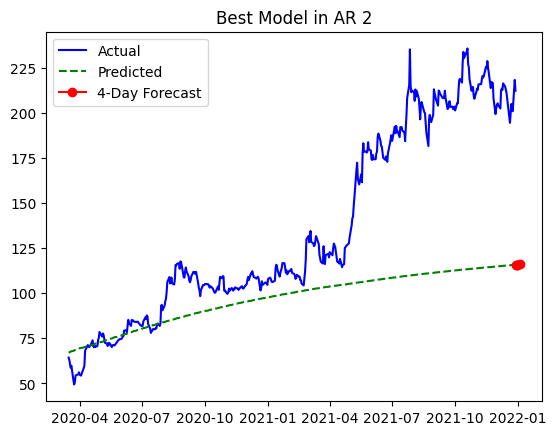

Best Model in MA:
 model           MA
order    (0, 0, 1)
trend            n
rmse      0.054817
mape       0.99997
Name: 0, dtype: object


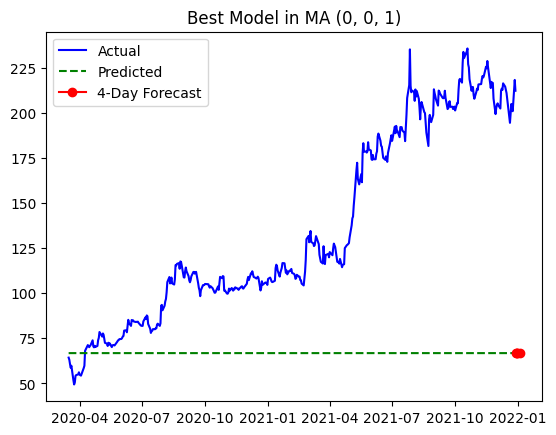

Best Model in ARMA:
 model         ARMA
order    (5, 0, 3)
trend            c
rmse      0.013786
mape      0.549405
Name: 57, dtype: object


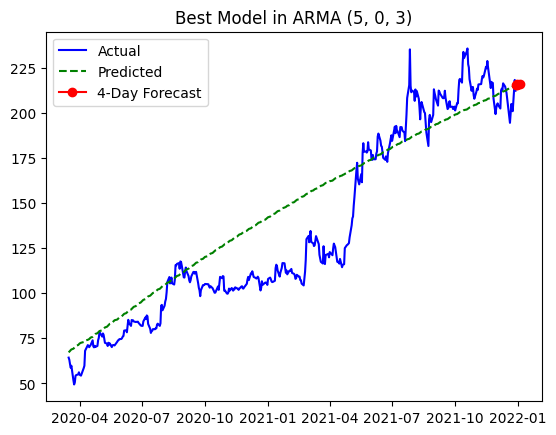

Best Model in ARIMA:
 model        ARIMA
order    (5, 0, 3)
trend            c
rmse      0.013786
mape      0.549405
Name: 105, dtype: object


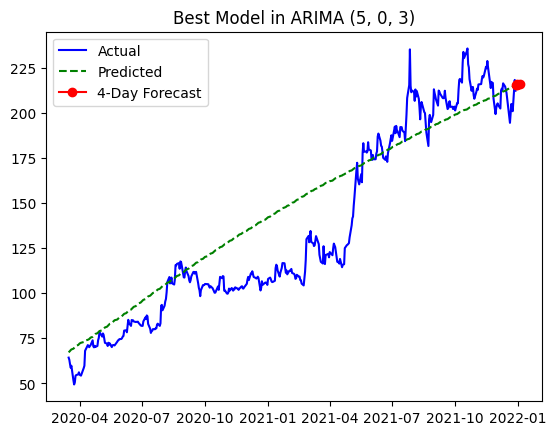

Best Model in SARIMA:
 model       SARIMA
order    (1, 0, 2)
trend           ct
rmse      0.040716
mape      0.783318
Name: 7, dtype: object


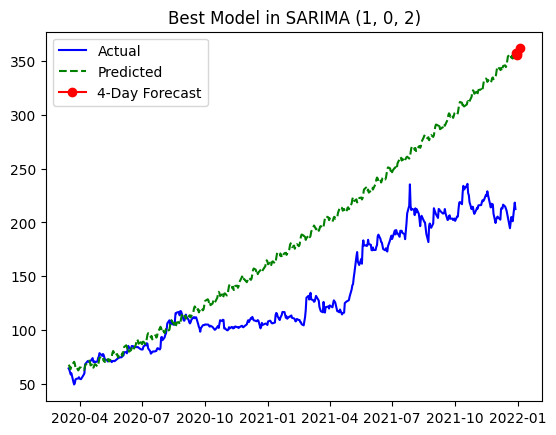



Winner: ARMA with RMSE: 0.0138 and MAPE: 0.5494


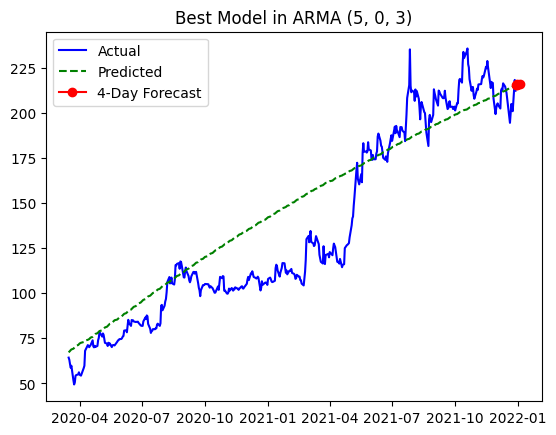

In [21]:
final_leaderboard = []
for name, orders, trends in model_configs:
    result = evaluate_model(name, train, test, orders, trends)
    best = result.iloc[0] if not result.empty else None
    if best is not None:
        final_leaderboard.append(best)
    print(f"Best Model in {name}:\n", best.iloc[:-1])
    finalize_and_plot(best, df, test_data, scaler)
# Select the ultimate winner across all model types
best_overall = pd.DataFrame(final_leaderboard).sort_values(["rmse", "mape"]).iloc[0]
print(f"\n\nWinner: {best_overall['model']} with RMSE: {best_overall['rmse']:.4f} and MAPE: {best_overall['mape']:.4f}")

finalize_and_plot(best_overall, df, test_data, scaler)
